In [2]:
pip install scikit-learn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.1 MB 18.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 14.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 14.5 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---- ----------------------------------- 3.9/37.3 MB 20.3 MB/s eta 0:00:02
   --------- ------------------------------ 8.7/37.3 MB 21.3 MB/s eta 0:00:02
   ------------- -------------------------- 12.8/37.3 MB 20.8 MB/s eta 0:00:02
   ----------------- ---------------------- 16.8/37.3 MB 20.1 MB/s eta 0:00:02
   --------------------- ------------------ 19.9/37.3 MB 19.1 MB/s eta 0:00:01
   -------------------------- ------------- 24.4/37.3 MB 19.5 MB/s eta 0:00:01
   ------------------------------ --------- 28.3/37.3 MB 19.6 MB/s eta 0:00:01
   -------------------------------- ------- 30.7/37.3 MB 18.4 MB/s eta 0:00:01
   

In [1]:

from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Handling Missing Values


## Complete Case Analysis
Kisi bhi row me kisi bhi column me agar mising value hai to row ko hi hata do

In [2]:
df = pd.read_csv("data_science_job.csv")

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [7]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [8]:
cols = []
for col in df.columns : 
    missing_precent = df[col].isnull().mean()

    if missing_precent >0 and missing_precent < 0.05 : 
        cols.append(col)

In [9]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [10]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
18172,0.920,no_enrollment,Graduate,10.0,45.0
11850,0.897,no_enrollment,Masters,7.0,76.0
4738,0.624,no_enrollment,Graduate,6.0,56.0
7126,0.884,Part time course,Masters,5.0,22.0
18072,0.579,Full time course,High School,3.0,94.0


In [11]:
new_df =  df[cols].dropna()

new_df.shape, df.shape

((17182, 5), (19158, 13))

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

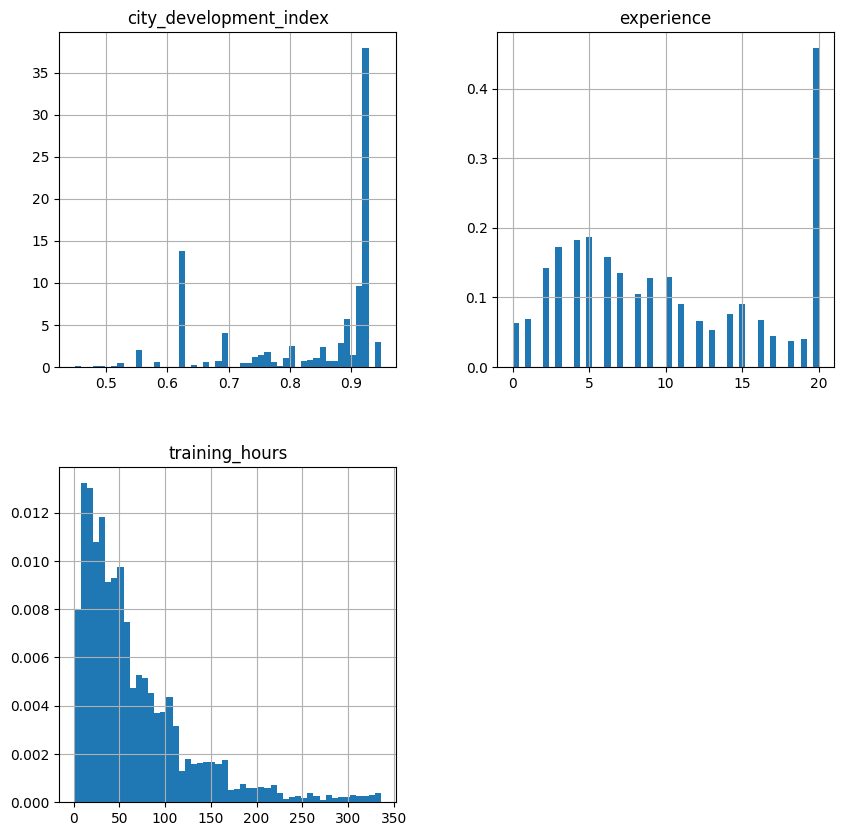

In [14]:
new_df.hist(bins=50, density=True, figsize=(10, 10))

<Axes: >

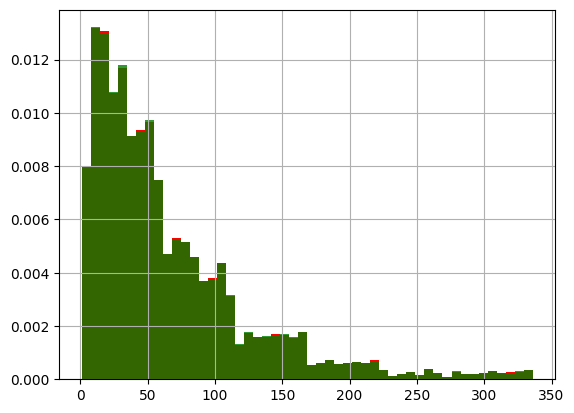

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)
df["training_hours"].hist(bins=50, ax=ax, density=True, color="red")
new_df["training_hours"].hist(bins=50, ax=ax, density=True, color="green", alpha=0.8)

<Axes: ylabel='Density'>

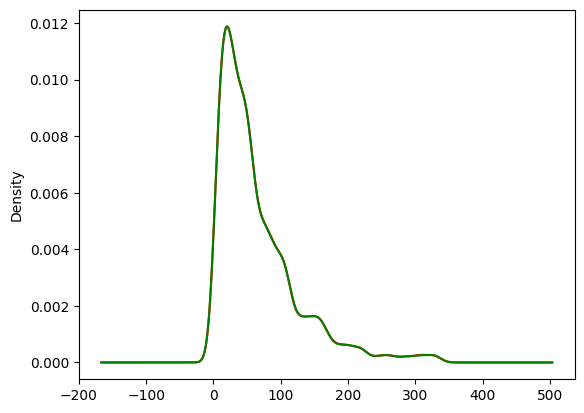

In [20]:
# jo data missing tha woh complete randomly missing hai iske help se
fig = plt.figure()
ax = fig.add_subplot(111)

df["training_hours"].plot.density(color="red")
new_df["training_hours"].plot.density(color="green")


In [21]:
# categorical column
df["education_level"].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [25]:
temp = pd.concat([
    df["enrolled_university"].value_counts() / len(df),
    new_df["enrolled_university"].value_counts() / len(new_df)
], axis=1)

temp.columns = ["original", "cca"]

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


## Simple Imputer in Numerical data

In [26]:
df = pd.read_csv("titanic_toy.csv")
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [28]:
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

#### 1. Mean/Median Imputation
* Mean :- If your data is Normal Distribution
* Median : if your data is skewed
- When to use
- Missing value is completly Random
- < 5%

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
x = df.drop(columns=["Survived"])
y = df["Survived"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)
imputer1 = SimpleImputer(strategy="median")
imputer2 = SimpleImputer(strategy="mean")

trf = ColumnTransformer([
    ("imputer1", imputer1,["Age"]),
    ("imputer2", imputer2,["Fare"]),
], remainder="passthrough")

trf.fit(x_train)
trf.named_transformers_["imputer1"].statistics_


array([28.75])

In [39]:
trf.named_transformers_["imputer2"].statistics_


array([32.61759689])

In [49]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [50]:
x_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))

# Incompleted data

In [41]:
df = pd.read_csv("placement.csv")

df.duplicated().sum()

df.drop_duplicates()


,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


# How to Handle Incorrect Data

In [ ]:
df = pd.DataFrame({
    "Age": [25, -5, 30, 200],
    "Gender": ["Male", "Mlae", "Female"]
})


# 1. Detect Incorrect Values
print(df[df["Age"] < 0])

# 2. Remove Incorrect Rows
df = df[df["Age"] >= 0]

# 3. Replace Incorrect Values
df["Gender"] = df["Gender"].replace("Mlae", "Male")

ValueError: All arrays must be of the same length

# Outlier detection using Z-score 

In [ ]:
# if your data is Normal distribution then use Z-score method
df = pd.read_csv("placement.csv")

df.sample(5)

,cgpa,placement_exam_marks,placed
843,6.31,60.0,0
119,7.00,39.0,0
587,7.58,14.0,1
533,7.19,15.0,0
8,6.45,38.0,0


C:\Users\Yash\AppData\Local\Temp\ipykernel_13228\3910714676.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["cgpa"])
C:\Users\Yash\AppData\Local\Temp\ipykernel_13228\3910714676.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["placement_exam_marks"])


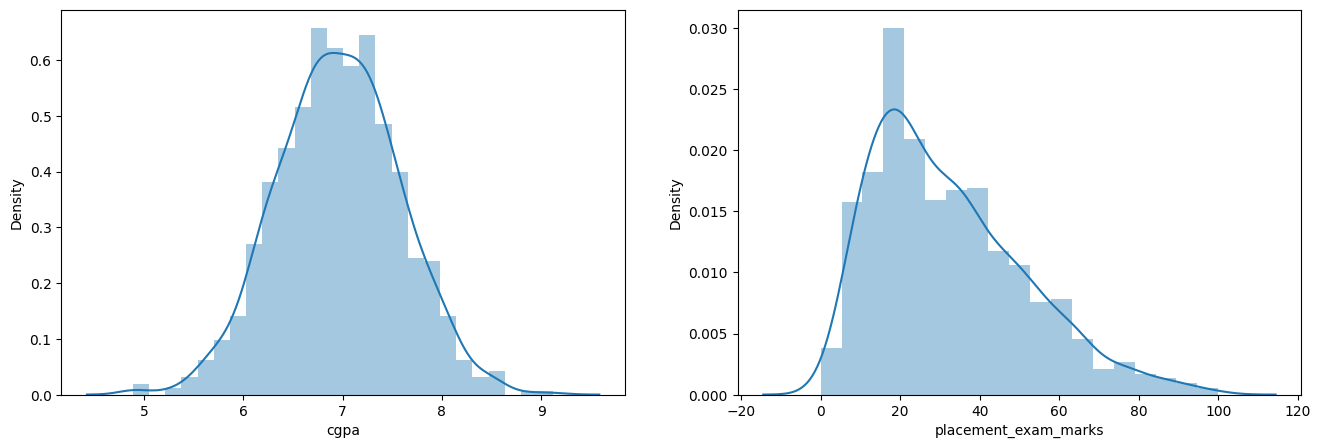

In [12]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df["cgpa"])

plt.subplot(1,2,2)
sns.distplot(df["placement_exam_marks"])

plt.show()

In [13]:
print("Mean value of cgpa :",df["cgpa"].mean())
print("Standed value of cgpa :",df["cgpa"].std())
print("Minnmum value of cgpa :",df["cgpa"].min())
print("Maximum value of cgpa :",df["cgpa"].max())

Mean value of cgpa : 6.96124
Standed value of cgpa : 0.6158978751323896
Minnmum value of cgpa : 4.89
Maximum value of cgpa : 9.12


In [ ]:
# find the boundary value
print("Highest value :", df["cgpa"].mean() + 3*df["cgpa"].std())
print("Lowest value :", df["cgpa"].mean() - 3*df["cgpa"].std())

Highest value : 8.808933625397168
Lowest value : 5.113546374602832


In [24]:
#Finding the outliers
df[(df["cgpa"] > 8.80) | (df["cgpa"] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [22]:
# if you want to Trimming the outliers
new_df = df[(df["cgpa"] < 8.80) & (df["cgpa"] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [ ]:
# Clapping

upper_limit = df["cgpa"].mean() + 3*df["cgpa"].std()
lower_limit = df["cgpa"].mean() - 3*df["cgpa"].std()


np.float64(5.113546374602832)

In [27]:
df["cgpa"] = np.where(
    df["cgpa"] > upper_limit, upper_limit, 
    np.where(
        df["cgpa"] < lower_limit, lower_limit, df["cgpa"]
    )
)

In [31]:
df.shape
df["cgpa"].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

# Outlier detection using IQR Method

In [4]:
# if your data is skewed then use IQR method

df = pd.read_csv("placement.csv")

df.sample(5)

,cgpa,placement_exam_marks,placed
702,6.24,39.0,0
506,7.84,8.0,1
110,6.96,31.0,0
345,6.26,13.0,1
681,6.78,10.0,1


C:\Users\Yash\AppData\Local\Temp\ipykernel_532\809771946.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["placement_exam_marks"])


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

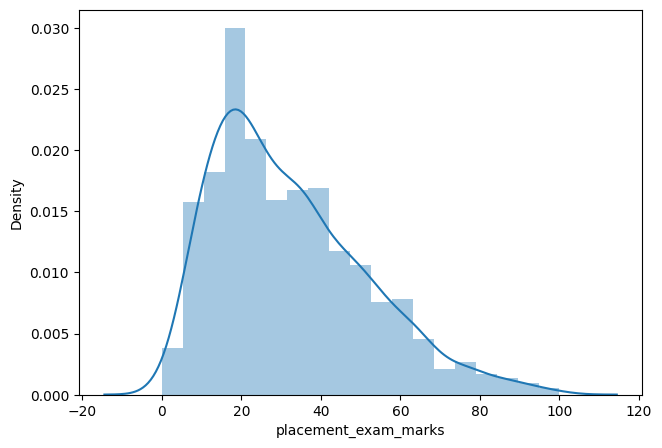

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df["placement_exam_marks"])

In [6]:
df["placement_exam_marks"].skew()

np.float64(0.8356419499466834)

In [7]:
df["placement_exam_marks"].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

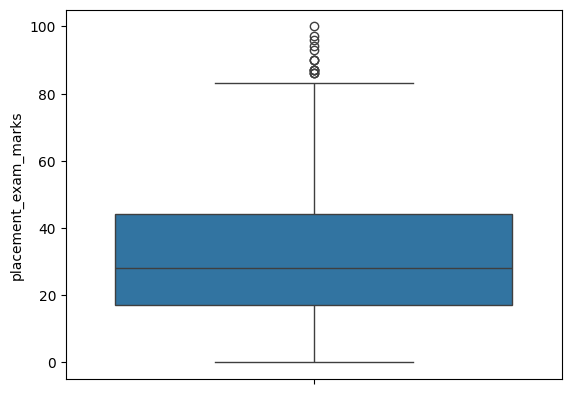

In [8]:
sns.boxplot(df["placement_exam_marks"])

In [9]:
# find the IQR
precentile25 = df["placement_exam_marks"].quantile(0.25)
precentile75 = df["placement_exam_marks"].quantile(0.75)

In [10]:
iqr = precentile75 - precentile25
iqr

np.float64(27.0)

In [11]:
upper_limit = precentile75 + 1.5 * iqr
lower_limit = precentile25 - 1.5 * iqr

In [12]:
print("Upper Limit : ", upper_limit)
print("Lower Limit : ", lower_limit)

Upper Limit :  84.5
Lower Limit :  -23.5


In [13]:
df[df["placement_exam_marks"] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [15]:
# Trimming
new_df = df[df["placement_exam_marks"] < upper_limit]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


C:\Users\Yash\AppData\Local\Temp\ipykernel_532\1658431890.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["placement_exam_marks"])
C:\Users\Yash\AppData\Local\Temp\ipykernel_532\1658431890.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df["placement_exam_marks"])


<Axes: ylabel='placement_exam_marks'>

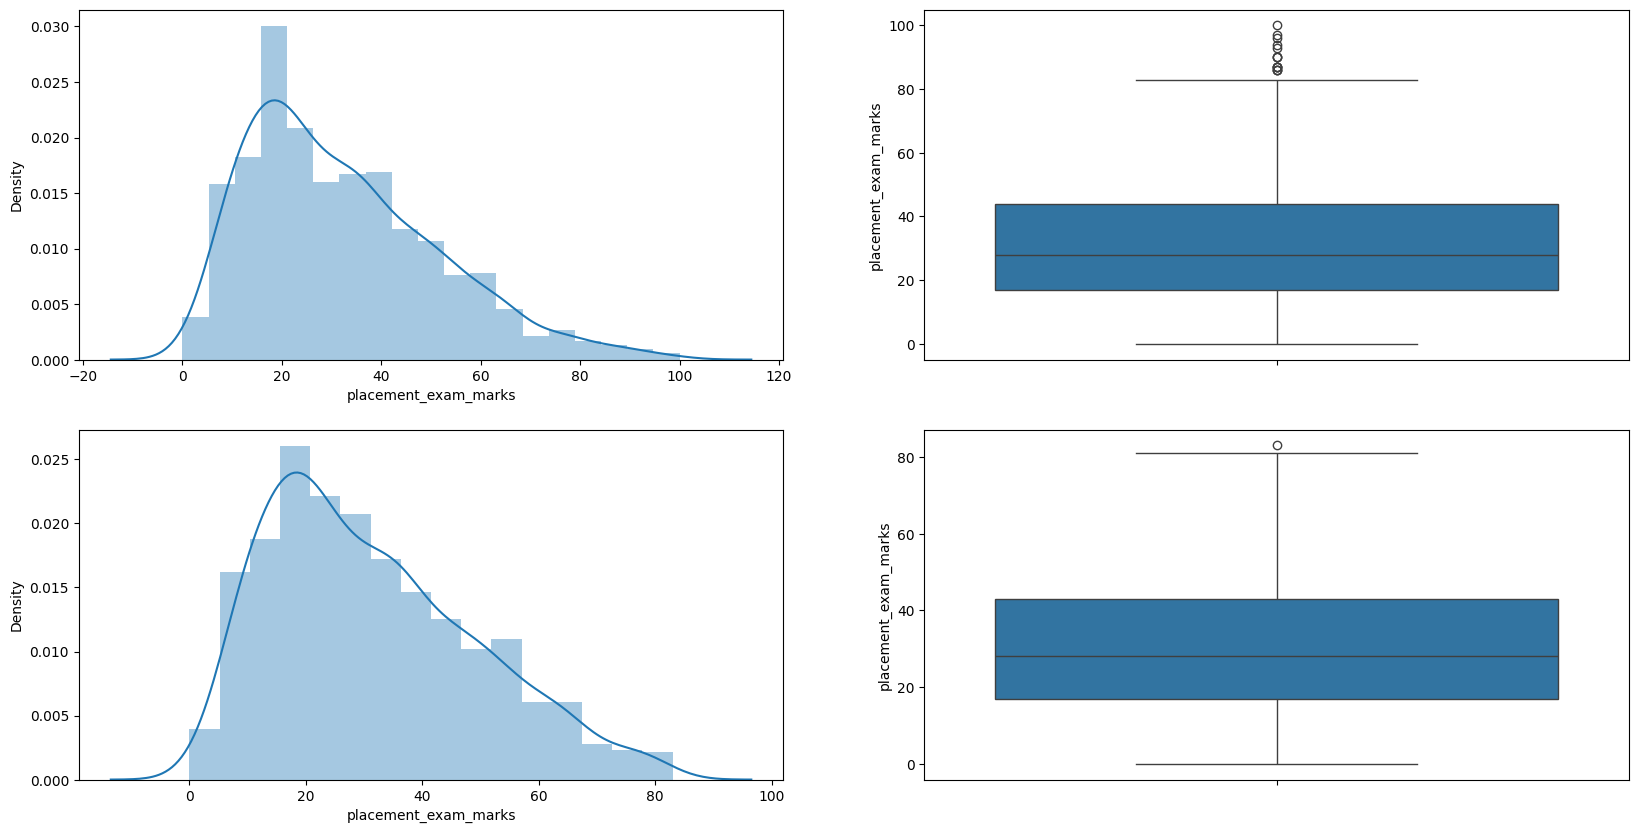

In [23]:
# Comparing

plt.figure(figsize=(20,10))
plt.subplot(2,2,1)
sns.distplot(df["placement_exam_marks"])

plt.subplot(2,2,2)
sns.boxplot(df["placement_exam_marks"])

plt.subplot(2,2,3)
sns.distplot(new_df["placement_exam_marks"])

plt.subplot(2,2,4)
sns.boxplot(new_df["placement_exam_marks"])

In [ ]:
# caping
new_df_cap = df.copy()

# np.where(condition, True, False)

new_df_cap["placement_exam_marks"] = np.where(new_df_cap["placement_exam_marks"] > upper_limit, upper_limit, np.where(
    new_df_cap["placement_exam_marks"] < lower_limit, lower_limit, new_df_cap["placement_exam_marks"]
))

In [22]:
new_df_cap.shape

(1000, 3)

C:\Users\Yash\AppData\Local\Temp\ipykernel_532\748066805.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["placement_exam_marks"])
C:\Users\Yash\AppData\Local\Temp\ipykernel_532\748066805.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap["placement_exam_marks"])


<Axes: ylabel='placement_exam_marks'>

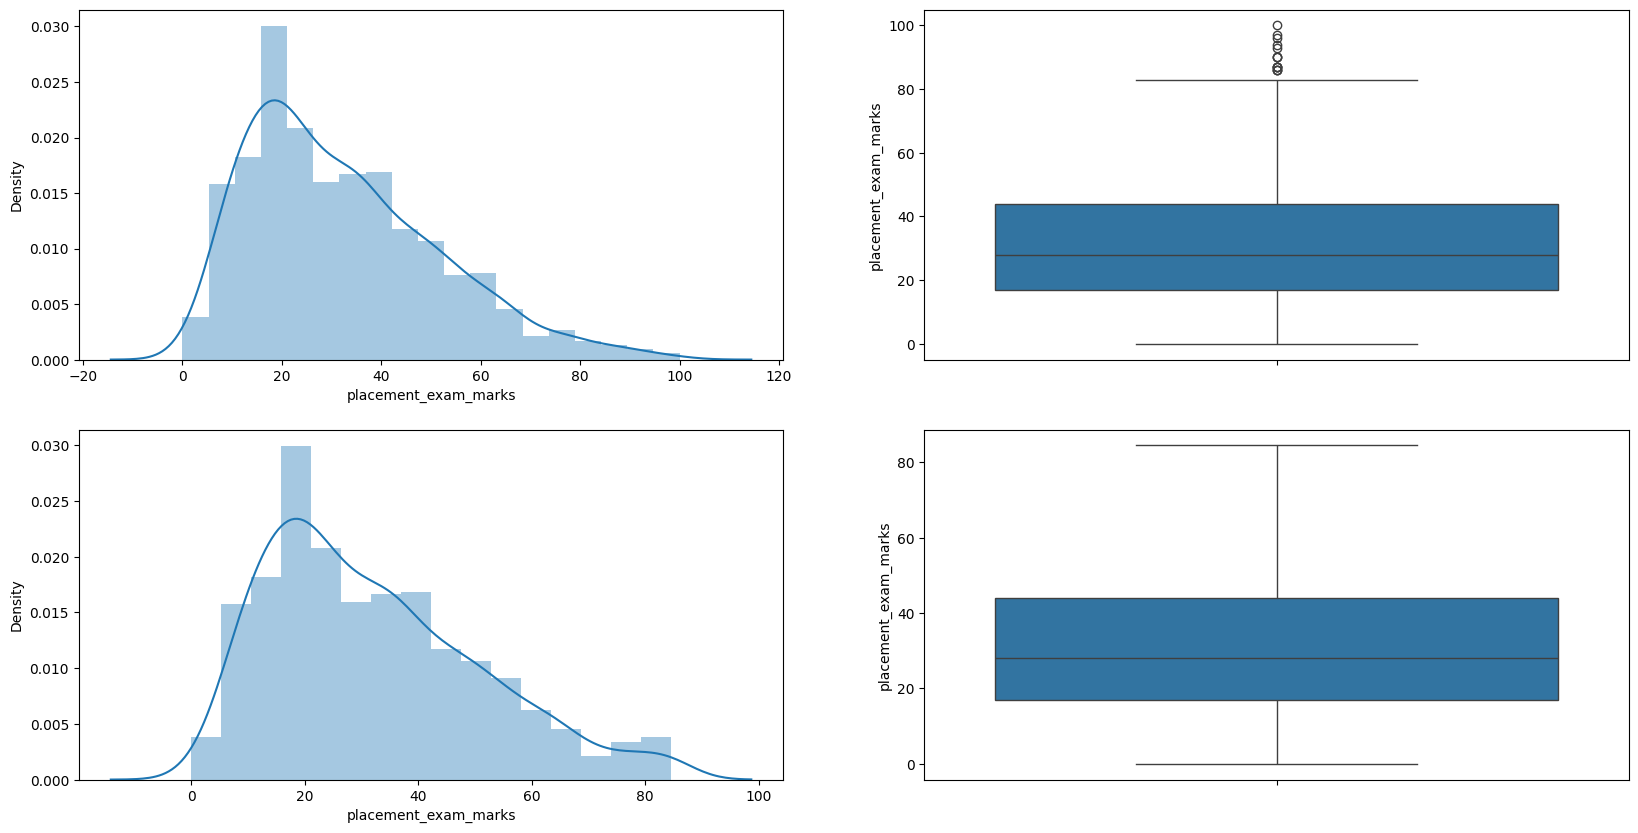

In [24]:
# Comparing

plt.figure(figsize=(20,10))
plt.subplot(2,2,1)
sns.distplot(df["placement_exam_marks"])

plt.subplot(2,2,2)
sns.boxplot(df["placement_exam_marks"])

plt.subplot(2,2,3)
sns.distplot(new_df_cap["placement_exam_marks"])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap["placement_exam_marks"])